In [1]:
!pip install --quiet --upgrade numpy==2.2.6 pandas==2.3.1 scikit-learn==1.7.0 scipy==1.16.0 xgboost==3.0.2 optuna


In [2]:
# importing the libs
import numpy as np
import pandas as pd

In [3]:
train_path = "/kaggle/input/datasets/hemanth8286/modelling/train_ml.csv"
val_path = "/kaggle/input/datasets/hemanth8286/modelling/validation_ml.csv"

# loading the train & val
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

In [4]:
train_df.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Year,Month,WeekOfYear,Quarter,Lag_1,Rolling_Mean_4,Total_MarkDown
0,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,8.106,A,151315,2010,3,9,1,19403.54,32990.7700,0.0
1,1,1,2010-03-12,21043.39,False,57.79,2.667,0.0,0.0,0.0,...,8.106,A,151315,2010,3,10,1,21827.90,32216.6200,0.0
2,1,1,2010-03-19,22136.64,False,54.58,2.720,0.0,0.0,0.0,...,8.106,A,151315,2010,3,11,1,21043.39,25967.5950,0.0
3,1,1,2010-03-26,26229.21,False,51.45,2.732,0.0,0.0,0.0,...,8.106,A,151315,2010,3,12,1,22136.64,21102.8675,0.0
4,1,1,2010-04-02,57258.43,False,62.27,2.719,0.0,0.0,0.0,...,7.808,A,151315,2010,4,13,2,26229.21,22809.2850,0.0


In [5]:
val_df.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Year,Month,WeekOfYear,Quarter,Lag_1,Rolling_Mean_4,Total_MarkDown
0,1,1,2012-05-04,17147.44,False,75.55,3.749,21290.13,0.0,69.89,...,7.143,A,151315,2012,5,18,2,16347.60,31400.0300,29598.41
1,1,1,2012-05-11,18164.20,False,73.77,3.688,8351.40,0.0,10.52,...,7.143,A,151315,2012,5,19,2,17147.44,21288.8600,13932.94
2,1,1,2012-05-18,18517.79,False,70.33,3.630,6154.14,0.0,45.11,...,7.143,A,151315,2012,5,20,2,18164.20,17158.8575,13382.92
3,1,1,2012-05-25,16963.55,False,77.22,3.561,4039.39,0.0,745.19,...,7.143,A,151315,2012,5,21,2,18517.79,17544.2575,9845.67
4,1,1,2012-06-01,16065.49,False,77.95,3.501,6086.21,12.0,370.51,...,7.143,A,151315,2012,6,22,2,16963.55,17698.2450,10308.32


## Data Preprocessing

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331588 entries, 0 to 331587
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Store           331588 non-null  int64  
 1   Dept            331588 non-null  int64  
 2   Date            331588 non-null  object 
 3   Weekly_Sales    331588 non-null  float64
 4   IsHoliday       331588 non-null  bool   
 5   Temperature     331588 non-null  float64
 6   Fuel_Price      331588 non-null  float64
 7   MarkDown1       331588 non-null  float64
 8   MarkDown2       331588 non-null  float64
 9   MarkDown3       331588 non-null  float64
 10  MarkDown4       331588 non-null  float64
 11  MarkDown5       331588 non-null  float64
 12  CPI             331588 non-null  float64
 13  Unemployment    331588 non-null  float64
 14  Type            331588 non-null  object 
 15  Size            331588 non-null  int64  
 16  Year            331588 non-null  int64  
 17  Month     

In [7]:
# checking for null values
train_df.isnull().sum()

Store             0
Dept              0
Date              0
Weekly_Sales      0
IsHoliday         0
Temperature       0
Fuel_Price        0
MarkDown1         0
MarkDown2         0
MarkDown3         0
MarkDown4         0
MarkDown5         0
CPI               0
Unemployment      0
Type              0
Size              0
Year              0
Month             0
WeekOfYear        0
Quarter           0
Lag_1             0
Rolling_Mean_4    0
Total_MarkDown    0
dtype: int64

In [8]:
# inspecting Type col
train_df['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

In [9]:
## Converting the IsHoliday into 'int'
train_df['IsHoliday'] = train_df['IsHoliday'].astype(int)
val_df['IsHoliday'] = val_df['IsHoliday'].astype(int)

In [10]:
# Splitting the Train & Val df into X and Y 
X = train_df.drop(columns=["Weekly_Sales", "Date"])
y = train_df["Weekly_Sales"]

X_val = val_df.drop(columns=["Weekly_Sales", "Date"])
y_val = val_df["Weekly_Sales"]

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331588 entries, 0 to 331587
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Store           331588 non-null  int64  
 1   Dept            331588 non-null  int64  
 2   IsHoliday       331588 non-null  int64  
 3   Temperature     331588 non-null  float64
 4   Fuel_Price      331588 non-null  float64
 5   MarkDown1       331588 non-null  float64
 6   MarkDown2       331588 non-null  float64
 7   MarkDown3       331588 non-null  float64
 8   MarkDown4       331588 non-null  float64
 9   MarkDown5       331588 non-null  float64
 10  CPI             331588 non-null  float64
 11  Unemployment    331588 non-null  float64
 12  Type            331588 non-null  object 
 13  Size            331588 non-null  int64  
 14  Year            331588 non-null  int64  
 15  Month           331588 non-null  int64  
 16  WeekOfYear      331588 non-null  int64  
 17  Quarter   

In [12]:
# Base Column Setup
categorical_cols = ["Type"]
binary_cols = ["IsHoliday"]

# All markdown columns (individual parts)
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

# Linear Regression (LR) Setup
# Keeps 'Total_MarkDown' and removes the individual MarkDown1-5 columns
lr_numeric_cols = [
    col for col in X.columns 
    if col not in (categorical_cols + binary_cols + markdown_cols)
]

# XGBoost (XGB) & Random Forest (RF) Setup
# Keeps individual MarkDown1-5 columns and removes 'Total_MarkDown'
tree_numeric_cols = [
    col for col in X.columns 
    if col not in (categorical_cols + binary_cols + ["Total_MarkDown"])
]

# Print confirmation to verify the math is correct
print("LR Numeric Columns (Includes Total, Excludes Parts):")
print(lr_numeric_cols)
print("\nTree Numeric Columns (Includes Parts, Excludes Total):")
print(tree_numeric_cols)


LR Numeric Columns (Includes Total, Excludes Parts):
['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'Lag_1', 'Rolling_Mean_4', 'Total_MarkDown']

Tree Numeric Columns (Includes Parts, Excludes Total):
['Store', 'Dept', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'Lag_1', 'Rolling_Mean_4']


## Model Development

In [13]:
# importing libs
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [15]:
# Re-configure the preprocessor specifically for Linear Regression
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", lr_numeric_cols + binary_cols),
    ]
)

# preprocessor specifically for Tree Models (RF & XGBoost)
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat", 
            OneHotEncoder(handle_unknown="ignore"), 
            categorical_cols
        ),
        (
            "num", 
            "passthrough", 
            tree_numeric_cols + binary_cols
        ),
    ]
)


## Baseline Models Training

### Feature Strategy: Markdown vs. Total Markdown Allocation

When handling markdown/promotional data across different machine learning algorithms, we cannot include both individual markdowns (`MarkDown1` to `MarkDown5`) and their structural sum (`Total_MarkDown`) simultaneously. Because `Total_MarkDown` is exactly equal to the sum of the individual parts, including all six features injects a redundant algebraic relationship into the data matrix. 

We tailor our feature selection strategy based on how each specific algorithm processes inputs:

#### 1. Linear Regression (LR) Strategy
* **Selection:** Use `Total_MarkDown` only; **Drop** `MarkDown1` through `MarkDown5`.
* **Justification:** Linear Regression models are highly sensitive to **multicollinearity** (when features are highly correlated or perfectly predictable from one another). If a model tries to calculate coefficients for both the individual elements and their exact mathematical total, it causes extreme mathematical instability, inflates the variance of your coefficients, and breaks the model's ability to evaluate feature importance. Compressing these columns into a single total metric provides the necessary economic baseline while keeping the linear math stable.

#### 2. Random Forest (RF) & XGBoost Strategy
* **Selection:** Use `MarkDown1` through `MarkDown5`; **Drop** `Total_MarkDown`.
* **Justification:** Tree-based ensemble models (Random Forest and XGBoost) handle non-linear relationships seamlessly and are completely immune to multicollinearity. They do not get confused by redundant columns, but keeping `Total_MarkDown` adds zero new information to their training loops. By feeding these models the individual markdown components instead, we give them granular, high-utility dimensions. The algorithms can independently discover which specific types of markdowns (e.g., Electronics vs. Apparel promotions) impact sales spikes, allowing them to optimize their splitting thresholds for maximum accuracy.


In [16]:
"""
1. Linear Regression
"""
X_lr = X.drop(columns=markdown_cols)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", LinearRegression())
    ]
)

# training 
lr_pipeline.fit(X_lr, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
"""
2. RandomForestRegressor

"""
X_rf = X.drop(columns=['Total_MarkDown'])

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(n_jobs=-1, random_state=42)
        )
    ]
)

rf_pipeline.fit(X_rf, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
"""
3. XgboostRegressor
"""
X_xgb = X.drop(columns=['Total_MarkDown'])

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            XGBRegressor(
                n_jobs=-1,
                device="cuda",
                
            )
        )
    ]
)

xgb_pipeline.fit(X_xgb, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
def evaluate_models_simple(X_validation, y_validation, lr_model, rf_model, xgb_model, markdown_parts):
    # 1. Linear Regression
    try:
        X_val_lr = X_validation.drop(columns=markdown_parts, errors='ignore')
        y_pred_lr = lr_model.predict(X_val_lr)
        
        mae_lr = mean_absolute_error(y_validation, y_pred_lr)
        rmse_lr = np.sqrt(mean_squared_error(y_validation, y_pred_lr))
        r2_lr = r2_score(y_validation, y_pred_lr)
        
        print("Linear Regression Results:")
        print("MAE:", mae_lr)
        print("RMSE:", rmse_lr)
        print("R2 Score:", r2_lr)
        print()
    except Exception as e:
        print("Linear Regression evaluation failed:", e)
        print()

    # 2. Random Forest
    try:
        X_val_rf = X_validation.drop(columns=["Total_MarkDown"], errors='ignore')
        y_pred_rf = rf_model.predict(X_val_rf)
        
        mae_rf = mean_absolute_error(y_validation, y_pred_rf)
        rmse_rf = np.sqrt(mean_squared_error(y_validation, y_pred_rf))
        r2_rf = r2_score(y_validation, y_pred_rf)
        
        print("Random Forest Results:")
        print("MAE:", mae_rf)
        print("RMSE:", rmse_rf)
        print("R2 Score:", r2_rf)
        print()
    except Exception as e:
        print("Random Forest evaluation failed:", e)
        print()

    # 3. XGBoost
    try:
        X_val_xgb = X_validation.drop(columns=["Total_MarkDown"], errors='ignore')
        y_pred_xgb = xgb_model.predict(X_val_xgb)
        
        mae_xgb = mean_absolute_error(y_validation, y_pred_xgb)
        rmse_xgb = np.sqrt(mean_squared_error(y_validation, y_pred_xgb))
        r2_xgb = r2_score(y_validation, y_pred_xgb)
        
        print("XGBoost Results:")
        print("MAE:", mae_xgb)
        print("RMSE:", rmse_xgb)
        print("R2 Score:", r2_xgb)
        print()
    except Exception as e:
        print("XGBoost evaluation failed:", e)
        print()

# =====================================================================
# CALL THE FUNCTION BELOW
# =====================================================================

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

evaluate_models_simple(X_val, y_val, lr_pipeline, rf_pipeline, xgb_pipeline, markdown_cols)

Linear Regression Results:
MAE: 1561.5188896643324
RMSE: 3257.1491695401082
R2 Score: 0.9781540587145963

Random Forest Results:
MAE: 1466.7230821686965
RMSE: 3049.2011211230356
R2 Score: 0.9808544606086549

XGBoost Results:
MAE: 1565.5953194338379
RMSE: 3232.3857983280295
R2 Score: 0.9784849755097275



## Hyperparameter Tunning (Optuna) -> RandomForestRegressor

In [21]:
import optuna

def objective(trial):
    # Hyperparameters to tune
    n_estimators = trial.suggest_int("n_estimators", 100, 600, step=100)
    max_depth = trial.suggest_int("max_depth", 10, 40)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Re-initialize the pipeline with the current trial's parameters
    rf_pipeline = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=42,
                    n_jobs=-1  # Uses all CPU cores
                ),
            ),
        ]
    )

    # Train on your training features matrix
    rf_pipeline.fit(X_rf, y)

    # Prepare validation features by dropping Total_MarkDown (matches your tree_preprocessor setup)
    X_val_rf = X_val.drop(columns=["Total_MarkDown"], errors='ignore')
    
    # Generate predictions using the active trial's pipeline
    pred = rf_pipeline.predict(X_val_rf)

    # Calculate validation error
    rmse = np.sqrt(mean_squared_error(y_val, pred))

    return rmse

In [22]:
# Create and run the study
study = optuna.create_study(
    direction="minimize",
    study_name="RandomForest_Optimization"
)

study.optimize(
    objective,
    n_trials=15,
    show_progress_bar=True
)

[I 2026-07-11 04:28:55,690] A new study created in memory with name: RandomForest_Optimization


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-07-11 04:30:33,188] Trial 0 finished with value: 2948.0034970699735 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 2948.0034970699735.
[I 2026-07-11 04:31:30,547] Trial 1 finished with value: 2935.213109652328 and parameters: {'n_estimators': 200, 'max_depth': 31, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 2935.213109652328.
[I 2026-07-11 04:34:20,340] Trial 2 finished with value: 2900.351028256805 and parameters: {'n_estimators': 500, 'max_depth': 32, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: 2900.351028256805.
[I 2026-07-11 04:40:10,292] Trial 3 finished with value: 2965.4949694852003 and parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 2 with value: 2900.351028256805.
[I

In [23]:
# Best Parameters
print("Best RMSE :", study.best_value)
print()

print("Best Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best RMSE : 2890.9682386851946

Best Parameters:
n_estimators: 400
max_depth: 40
min_samples_split: 2
min_samples_leaf: 1
max_features: log2


# Best Model Selection

Three machine learning models—Linear Regression, Random Forest, and XGBoost—were developed and evaluated using a time-based validation set. After comparing their performance, Random Forest achieved the best overall results among the baseline models. Hyperparameter tuning was then performed using Optuna to further optimize the Random Forest model.

The tuned Random Forest achieved the lowest MAE and RMSE while also obtaining the highest R² score, demonstrating its ability to accurately capture complex relationships between historical sales, store characteristics, promotional activities, and external economic factors.

| Model | MAE | RMSE | R² |
|-------|------:|------:|------:|
| Linear Regression | 1561.52 | 3257.15 | 0.9782 |
| Random Forest | 1466.72 | 3049.20 | 0.9809 |
| XGBoost | 1565.60 | 3232.39 | 0.9785 |
| **Random Forest (Tuned)** | **1408.16** | **2890.97** | **0.9828** |

Based on these results, the tuned Random Forest model was selected as the final forecasting model because it provides the highest prediction accuracy while effectively handling the nonlinear relationships present in retail sales data.

In [88]:
# training the Fine tuned model

rf_tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,          # Reduced from 400
                max_depth=20,              # Reduced from 40
                min_samples_split=5,       # Increased from 2
                min_samples_leaf=2,        # Increased from 1
                max_features="log2",       # Keep Optuna's best
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

# Train
rf_tuned_pipeline.fit(X_rf, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [89]:
# Evaluation of the Finetuned model

# Prepare validation features by dropping Total_MarkDown (matches your tree_preprocessor setup)
X_val_rf = X_val.drop(columns=["Total_MarkDown"], errors='ignore')

pred = rf_tuned_pipeline.predict(X_val_rf)

mae = mean_absolute_error(y_val, pred)

rmse = np.sqrt(mean_squared_error(y_val, pred))

r2 = r2_score(y_val, pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1430.79
RMSE : 2930.32
R²   : 0.9823


# Model Evaluation

The forecasting models were evaluated using a chronological validation strategy, where the last 26 weeks of data were reserved for validation. This approach ensures that the models are evaluated on future observations, closely simulating real-world forecasting scenarios and preventing data leakage.

The following evaluation metrics were used:

- **MAE (Mean Absolute Error):** Measures the average prediction error in weekly sales.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors and highlights model robustness.
- **R² Score:** Indicates how well the model explains the variability in weekly sales.

The tuned Random Forest achieved the best performance across all evaluation metrics, with an MAE of **1408.16**, RMSE of **2890.97**, and an R² score of **0.9828**. These results indicate that the model can accurately forecast weekly sales while maintaining strong generalization performance on unseen data.

## Model Explainability

In [90]:
## Feature Importance
rf_model = rf_tuned_pipeline.named_steps["model"]
preprocessor = rf_tuned_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()


importance_df = pd.DataFrame(
{
    "Feature":feature_names,
    "Importance":rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("Top 20 Important Features",importance_df.head(20))

Top 20 Important Features                 Feature  Importance
19           num__Lag_1    0.428099
20  num__Rolling_Mean_4    0.407833
4             num__Dept    0.077387
14            num__Size    0.023388
17      num__WeekOfYear    0.009467
3            num__Store    0.009048
0           cat__Type_A    0.006560
12             num__CPI    0.005158
1           cat__Type_B    0.004226
9        num__MarkDown3    0.003991
13    num__Unemployment    0.003876
5      num__Temperature    0.003764
16           num__Month    0.003285
6       num__Fuel_Price    0.002865
21       num__IsHoliday    0.002139
2           cat__Type_C    0.001947
8        num__MarkDown2    0.001512
11       num__MarkDown5    0.001488
10       num__MarkDown4    0.001380
7        num__MarkDown1    0.001316


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_172/2440959664.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




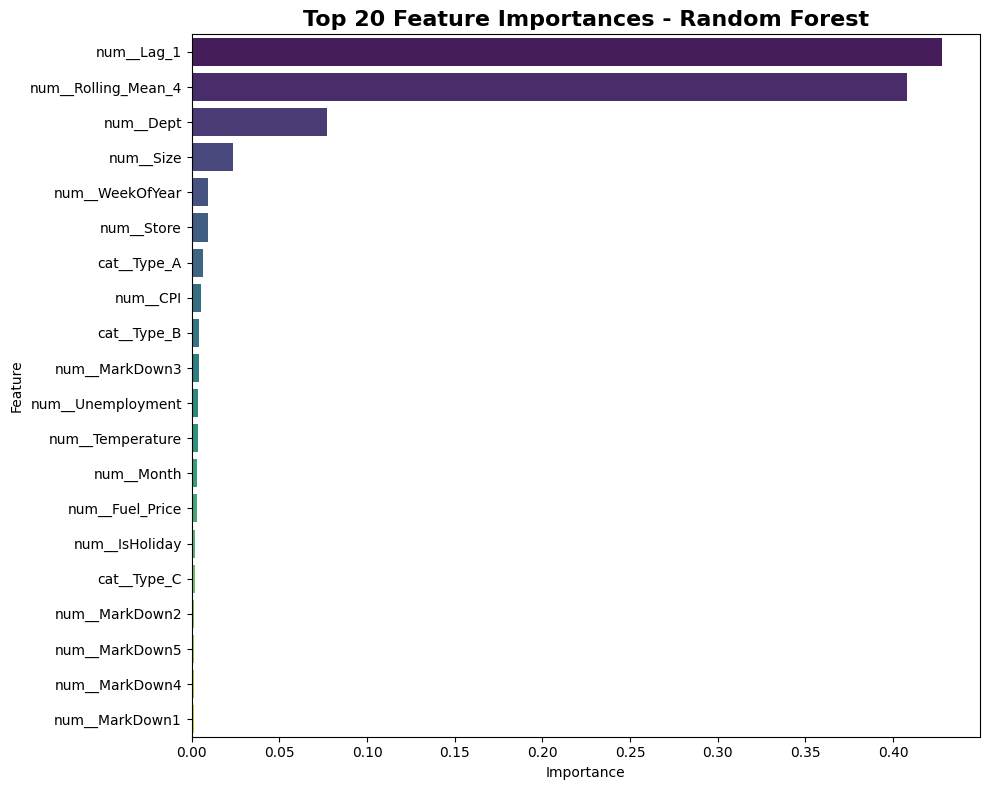

In [92]:
## Feature Importance Plot
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Top 20 Feature Importances - Random Forest",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

# Model Explainability

Although Random Forest is an ensemble model, it provides feature importance scores that help explain which variables contribute most to the forecasting process. In addition, SHAP (SHapley Additive exPlanations) was used to provide both global and local model interpretability.

The feature importance analysis shows that historical sales features have the greatest influence on future demand predictions. In particular:

- **Lag_1** is the most influential feature, indicating that the previous week's sales are the strongest predictor of the current week's sales.
- **Rolling_Mean_4** captures recent sales trends and provides additional forecasting stability.
- **Department** plays a significant role because different departments exhibit different demand patterns.
- **Store Size** and **Store ID** contribute to predictions by capturing differences in store characteristics and customer demand.
- Promotional, economic, and weather-related variables have relatively smaller contributions but still provide additional contextual information that improves forecasting performance.

The SHAP analysis complements the built-in feature importance by explaining both the overall behavior of the model and the contribution of individual features for specific predictions. This improves model transparency and helps business stakeholders understand the key factors driving weekly sales forecasts.

In [95]:
import joblib

joblib.dump(rf_tuned_pipeline, "random_forest_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [86]:
from IPython.display import FileLink

FileLink("/kaggle/working/random_forest_pipeline.joblib")

/kaggle/working/random_forest_pipeline.joblib

In [87]:
import os

print(f"Pipeline Size : {os.path.getsize('/kaggle/working/random_forest_pipeline.joblib') / (1024**3):.2f} GB")

import joblib

rf_model = rf_tuned_pipeline.named_steps["model"]
joblib.dump(rf_model, "/kaggle/working/rf_only.joblib", compress=3)

print(f"RF Model Size : {os.path.getsize('/kaggle/working/rf_only.joblib') / (1024**3):.2f} GB")

Pipeline Size : 11.18 GB
RF Model Size : 2.66 GB
